In [ ]:
!pip install ns3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 MB 9.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 9.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached cppyy_backend-1.15.2-py2.py3-none-linux_x86_64.whl
  Using cached cppyy_cling-6.30.0-py2.py3-none-manylinux2014_x86_64.whl (42.2 MB)
  Created wheel for cppyy: filename=cppyy-3.1.2-py3-none-any.whl size=17452581 sha256=b5b02d3310706fbe7b379eb62632b8e777af22fd02531630b6c95cf1ec288df6
  Stored in directory: /root/.cache/pip/wheels/3b/40/1b/ada0b9c0daefb13b28e744a899088caad6b53bafd00ce150cc
  Created wheel for CPyCppyy: filename=CPyCppyy-1.12.16-cp310-cp310-linux_x86_64.whl size=4590900 sha256=9470b6f93567f1

In [ ]:
import sys
sys.path.append("./ns-3-dev/build/bindings/python")
sys.path.append("./ns-3-dev/build/lib")
from ns import ns

In [ ]:
from matplotlib import pyplot as plt

# Get the coordinates for each node in the NodeContainer and plot
def plotNodePosition(nodeContainer : ns.NodeContainer, showLegend: bool = False) -> None:
    for node_i in range(nodeContainer.GetN()):
        node = nodeContainer.Get(node_i).__deref__()
        mobility = node.GetObject[ns.MobilityModel]().__deref__()
        position = mobility.GetPosition()
        plt.scatter((position.x), (position.y), label=f"Node {node.GetId()}")
    plt.ylabel("Y (m)")
    plt.xlabel("X (m)")
    if showLegend:
        plt.legend()
    plt.show()

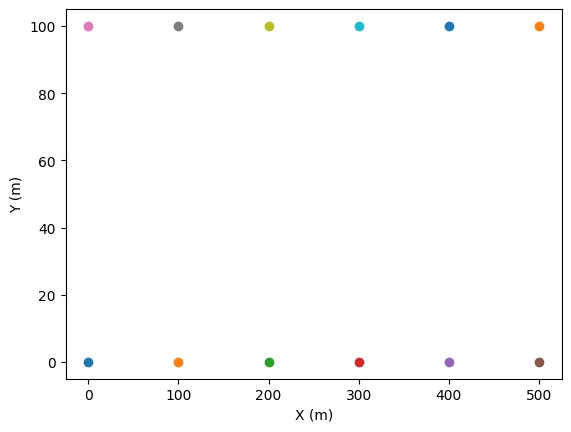

In [ ]:
def plotNodesInLineTopology():
    ns.Simulator.Destroy()

    # Create a topology with two rows with 5 nodes
    nodes = ns.NodeContainer()
    nodes.Create(12)

    linePositions = ns.CreateObject[ns.ListPositionAllocator]()
    for line in range(3):
        for column in range(6):
            linePositions.__deref__().Add (ns.Vector(100*column, 100*line, 0))

    mobilityHelper = ns.MobilityHelper()
    mobilityHelper.SetMobilityModel ("ns3::ConstantPositionMobilityModel")
    mobilityHelper.SetPositionAllocator (linePositions)
    mobilityHelper.Install (nodes)

    plotNodePosition(nodes)

plotNodesInLineTopology()

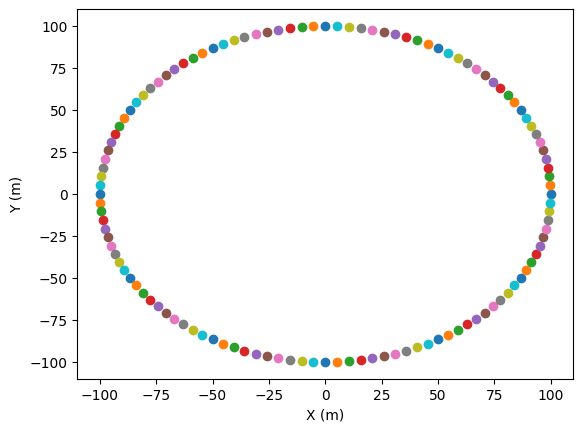

In [ ]:
def plotNodesInCircleTopology():
    import math
    ns.Simulator.Destroy()

    # Create a circular topology
    nodes = ns.NodeContainer()
    nodes.Create(120)

    linePositions = ns.CreateObject[ns.ListPositionAllocator]()
    radius = 100
    degPerNode = 2*math.pi / nodes.GetN()
    for node_i in range(nodes.GetN()):
        linePositions.__deref__().Add (ns.Vector(radius*math.cos(degPerNode*node_i),
                                                 radius*math.sin(degPerNode*node_i),
                                                 0))

    mobilityHelper = ns.MobilityHelper()
    mobilityHelper.SetMobilityModel ("ns3::ConstantPositionMobilityModel")
    mobilityHelper.SetPositionAllocator (linePositions)
    mobilityHelper.Install (nodes)

    plotNodePosition(nodes)

plotNodesInCircleTopology()

In [ ]:
def plotNodePositionAndChannels(nodeContainer : ns.NodeContainer, showLegend: bool = False) -> None:
    nodeIdToCoordinate = {}
    channelIdToNodeIds = {}
    for node_i in range(nodeContainer.GetN()):
        node = nodeContainer.Get(node_i).__deref__()
        nodeId = node.GetId()
        mobility = node.GetObject[ns.MobilityModel]().__deref__()
        position = mobility.GetPosition()
        nodeIdToCoordinate[nodeId] = (position.x, position.y)
        for device_i in range(node.GetNDevices()):
            netdevice = node.GetDevice(device_i).__deref__()
            if hasattr(netdevice, "GetChannel"):
                channel = netdevice.GetChannel().__deref__()
                channelId = channel.GetId()
                if channelId not in channelIdToNodeIds:
                    channelIdToNodeIds[channelId] = []
                channelIdToNodeIds[channelId].append(nodeId)
        plt.scatter((position.x), (position.y), label=f"Node {node.GetId()}")

    for (channelId, channelNodes) in channelIdToNodeIds.items():
        for i in range(len(channelNodes)):
            for j in range(i, len(channelNodes)):
                node_i = nodeIdToCoordinate[channelNodes[i]]
                node_j = nodeIdToCoordinate[channelNodes[j]]
                plt.plot([node_i[0], node_j[0]], [node_i[1], node_j[1]], label=f"Channel {channelId}")

    plt.ylabel("Y (m)")
    plt.xlabel("X (m)")
    if showLegend:
        plt.legend()
    plt.show()

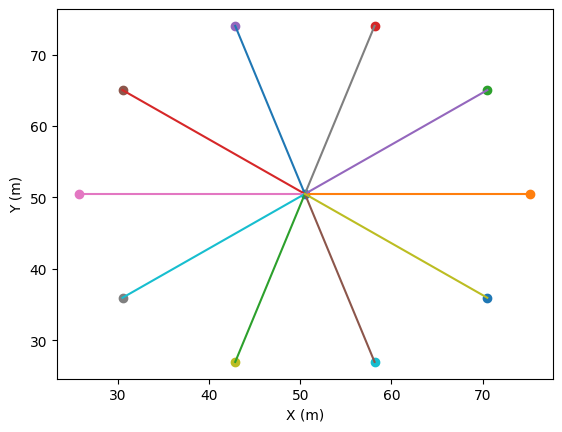

In [ ]:
def plotNodesInStarTopology():
    ns.Simulator.Destroy()

    # Create point-to-point star topology with 20 nodes
    pointToPoint = ns.PointToPointHelper()
    star = ns.PointToPointStarHelper(10, pointToPoint)
    star.BoundingBox(1, 1, 100, 100);

    # Get node container to plot the topology
    nodes = ns.NodeContainer()
    nodes.Add(star.GetHub())
    for node_i in range(star.SpokeCount()):
        nodes.Add(star.GetSpokeNode(node_i))

    plotNodePositionAndChannels(nodes, showLegend=False)

plotNodesInStarTopology()

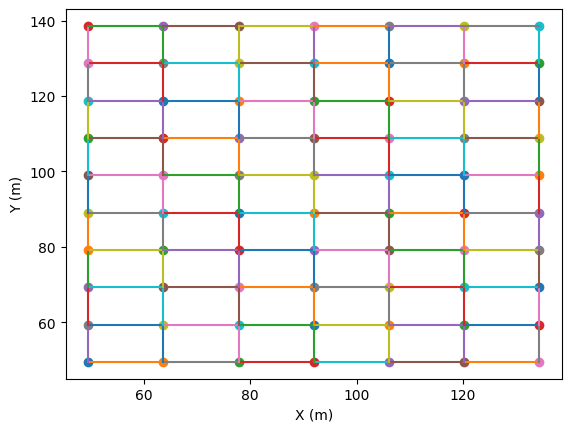

In [ ]:
def plotNodesInGridTopology():
    ns.Simulator.Destroy()

    # Create point-to-point grid topology with 20 nodes
    pointToPoint = ns.PointToPointHelper()
    grid = ns.PointToPointGridHelper(10,7, pointToPoint)
    grid.BoundingBox(1, 1, 100, 100);

    # Get node container to plot the topology
    nodes = ns.NodeContainer()
    for node_i in range(10):
        for node_j in range(7):
            nodes.Add(grid.GetNode(node_i, node_j))

    plotNodePositionAndChannels(nodes, showLegend=False)

plotNodesInGridTopology()

In [ ]:
coordinatesHistoric = []

# Create an event in C++ for the following python function
ns.cppyy.cppdef("""
   #ifndef pymakeevent
   #define pymakeevent
   namespace ns3
   {
       EventImpl* pythonMakeEvent(void (*f)(NodeContainer&), NodeContainer& nodes)
       {
           return MakeEvent(f, nodes);
       }
   }
   #endif
""")

def getNodeCoordinates(nodeContainer : ns.NodeContainer) -> None:
    global coordinatesHistoric

    coordinates = {}
    for node_i in range(nodeContainer.GetN()):
        node = nodeContainer.Get(node_i).__deref__()
        mobility = node.GetObject[ns.MobilityModel]().__deref__()
        position = mobility.GetPosition()
        coordinates[f"Node {node.GetId()}"] = ((position.x), (position.y))
    coordinatesHistoric.append((ns.Simulator.Now().GetSeconds(), coordinates))

    # Re-schedule after every 1 second
    event = ns.pythonMakeEvent(getNodeCoordinates, nodeContainer)
    ns.Simulator.Schedule(ns.Seconds(1), event)

def animateSimulation():
    global coordinatesHistoric

    # Save a copy and clean historic for the next animation
    coordinatesHistoricCopy = coordinatesHistoric
    coordinatesHistoric = []

    # Animate coordinates from the simulation
    from matplotlib import pyplot as plt
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML

    fig = plt.figure()
    plots = {}
    def init():
        # Initialize animation artists
        for (node, coordinate) in coordinatesHistoricCopy[0][1].items():
            plots[node] = plt.scatter(*coordinate, label=node)

        # Determine animation bounds
        x_bounds = [999999,0]
        y_bounds = [999999,0]
        for i in range(len(coordinatesHistoricCopy)):
            for (node, coordinate) in coordinatesHistoricCopy[i][1].items():
                if (coordinate[0] < x_bounds[0]):
                    x_bounds[0] = coordinate[0]
                if (coordinate[0] > x_bounds[1]):
                    x_bounds[1] = coordinate[0]
                if (coordinate[1] < y_bounds[0]):
                    y_bounds[0] = coordinate[1]
                if (coordinate[1] > y_bounds[1]):
                    y_bounds[1] = coordinate[1]

        # Add a margin to the bounds
        x_bounds[0] -= 1
        y_bounds[0] -= 1
        x_bounds[1] += 1
        y_bounds[1] += 1

        # Set animation bounds
        plt.xlim(x_bounds)
        plt.ylim(y_bounds)

    def animate(i):
        for (node, coordinate) in coordinatesHistoricCopy[i][1].items():
            plots[node].set_offsets(coordinate)

    # Animate the historic of coordinates
    anim = FuncAnimation(fig, animate, init_func=init,
                         frames = len(coordinatesHistoricCopy),
                         interval = 100, repeat=True)

    # Display the interactive animation
    display(HTML(anim.to_jshtml()))

    # Prevent plotting the final frame as a static image
    plt.close()
    return

In [ ]:
# Test the animation
coordinatesHistoric = [(0.0, {"Node 1": (0.0, 0.0), "Node 2": (1.0, 1.0)}),
                       (1.0, {"Node 1": (10.0, 0.0), "Node 2": (9.0, 1.0)}),
                       (2.0, {"Node 1": (10.0, 10.0), "Node 2": (9.0, 9.0)}),
                       (3.0, {"Node 1": (0.0, 10.0), "Node 2": (1.0, 9.0)}),
                       (4.0, {"Node 1": (4,4), "Node 2": (6,4)}),
                       ]
animateSimulation()